# AICE Associate 예상 문제 2회: 부동산 가격 예측

**과제: 지역별 부동산 가격 예측 AI 모델 개발**

**도메인: 부동산**

**배경:**
부동산 가격은 다양한 요인에 의해 복합적으로 결정됩니다. 'AICE 부동산' 데이터팀은 고객들이 합리적인 의사결정을 내릴 수 있도록, 축적된 실거래가 데이터를 기반으로 부동산의 가치를 예측하는 AI 모델을 구축하고자 합니다. 이 모델은 매물의 기본 정보와 주변 환경 요소를 바탕으로 적정 가격을 예측하여, 시장 투명성을 높이는 데 기여할 것입니다.

**데이터셋 설명 (파일명: `2_real_estate_valuation.csv`)**

* `region`: 지역
* `area_sqm`: 면적 (제곱미터)
* `num_rooms`: 방 개수
* `num_bathrooms`: 욕실 개수
* `building_age`: 건물 나이 (년)
* `building_material`: 주요 건축 자재
* `parking_spaces`: 주차 가능 대수
* `subway_stations_1km`: 반경 1km 내 지하철역 수
* `amenities_500m`: 반경 500m 내 편의시설 수
* `school_score`: 학군 점수
* **`price_eok`**: **예측 목표(Target)**, 부동산의 실제 거래 가격 (단위: 억 원)

--- 
#### **사전 실행 코드**
> 모든 문제를 풀기 전에 아래 코드를 실행해주세요.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

--- 
#### **문제 1.**

`LightGBM`은 Microsoft에서 개발한 고성능 그래디언트 부스팅 라이브러리입니다. `lightgbm` 라이브러리를 별칭 `lgb`로 임포트하는 코드를 작성하세요.

In [4]:
# 여기에 답안코드를 작성하세요.
import lightgbm as lgb

#### **[해설 및 핵심 이론] 문제 1**


* **상세 해설**  
    `import 라이브러리 as 별칭` 구문을 사용하여 `lightgbm` 라이브러리를 `lgb`라는 표준 별칭으로 불러옵니다.  
   `lightgbm`은 XGBoost와 함께 데이터 분석 대회에서 자주 사용되는 고성능 그래디언트 부스팅 라이브러리입니다.

In [ ]:
import lightgbm as lgb

--- 
#### **문제 2.**

AI 모델링을 위해 분석할 데이터를 준비하고 기본 정보를 파악하려고 합니다. 아래 가이드에 따라 코드를 작성하세요.

1.  Pandas의 `read_csv` 함수를 사용하여 `2_real_estate_valuation.csv` 파일을 읽어 데이터프레임 변수 `estate_df`에 할당하세요.
2.  `info()`와 `describe()` 함수를 사용하여 `estate_df`의 요약 정보와 기술 통계량을 확인하세요.

In [7]:
# 여기에 답안코드를 작성하세요.
estate_df = pd.read_csv('2_real_estate_valuation.csv')
estate_df.info()
estate_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               1500 non-null   object 
 1   area_sqm             1500 non-null   float64
 2   num_rooms            1456 non-null   float64
 3   num_bathrooms        1467 non-null   float64
 4   building_age         1459 non-null   float64
 5   building_material    1453 non-null   object 
 6   parking_spaces       1455 non-null   float64
 7   subway_stations_1km  1451 non-null   float64
 8   amenities_500m       1500 non-null   float64
 9   school_score         1500 non-null   float64
 10  price_eok            1500 non-null   float64
dtypes: float64(9), object(2)
memory usage: 129.0+ KB


,area_sqm,num_rooms,num_bathrooms,building_age,parking_spaces,subway_stations_1km,amenities_500m,school_score,price_eok
count,1500.000000,1456.000000,1467.000000,1459.000000,1455.000000,1451.000000,1500.000000,1500.000000,1500.000000
mean,123.692000,3.014423,2.006135,19.608636,1.751890,1.463129,6.911333,5.355333,27.123733
std,44.412913,1.387400,0.807090,11.449344,0.601141,1.130388,4.241320,2.914344,6.945192
min,50.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,6.200000
25%,83.000000,2.000000,1.000000,10.000000,1.000000,0.000000,3.000000,3.000000,22.100000
50%,123.000000,3.000000,2.000000,20.000000,2.000000,1.000000,7.000000,5.000000,27.150000
75%,161.250000,4.000000,3.000000,30.000000,2.000000,2.000000,10.250000,8.000000,31.900000
max,199.000000,5.000000,3.000000,39.000000,3.000000,3.000000,14.000000,10.000000,46.600000


#### **[해설 및 핵심 이론] 문제 2**


* **상세 해설**  
    `pandas`의 `read_csv()` 함수로 데이터를 불러온 후, `info()`와 `describe()`를 순차적으로 실행합니다.  
   `info()`는 데이터의 전체적인 구조와 결측치 현황을, `describe()`는 수치형 데이터의 통계적 특성을 보여주어 데이터에 대한 초기 탐색을 효율적으로 수행할 수 있게 합니다.

In [ ]:
# '2_real_estate_valuation.csv' 파일을 읽어 estate_df 변수에 저장합니다.
estate_df = pd.read_csv('../data/2_real_estate_valuation.csv')

# 데이터프레임의 요약 정보 확인
estate_df.info()

# 수치형 데이터의 기술 통계량 확인
print(estate_df.describe())

--- 
#### **문제 3.**

`면적(area_sqm)`과 `가격(price_eok)` 사이의 관계를 시각적으로 탐색하고, `학군점수(school_score)`가 이 관계에 미치는 영향을 확인하고자 합니다.  
`seaborn`의 `scatterplot`을 사용하여 아래 조건에 맞는 산점도를 생성하세요.

* **x축**: `area_sqm`
* **y축**: `price_eok`
* **데이터**: `estate_df`
* **추가 옵션**: 점의 색상(`hue`)을 `school_score` 기준으로 구분하여 표시

<Axes: xlabel='area_sqm', ylabel='price_eok'>

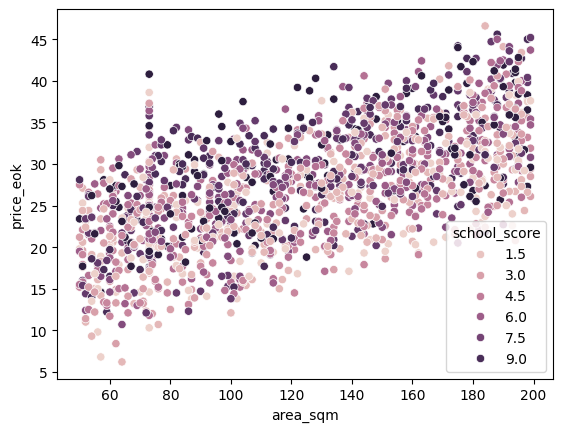

In [8]:
# 여기에 답안코드를 작성하세요.
sns.scatterplot(data=estate_df, x='area_sqm', y='price_eok', hue='school_score')

#### **[해설 및 핵심 이론] 문제 3**


* **상세 해설**  
    `seaborn`의 `scatterplot`은 두 수치형 변수 간의 관계를 점으로 나타내는 산점도를 그립니다. `x`축에 `area_sqm`, `y`축에 `price_eok`를 설정하면 면적이 넓어질수록 가격이 높아지는 경향을 확인할 수 있습니다. 여기에 `hue='school_score'` 옵션을 추가하면, 각 점의 색상이 학군 점수에 따라 다르게 표시되어, 학군 점수가 높은(색이 밝은) 매물들이 전반적으로 높은 가격대에 분포하는 경향까지 한 번에 파악할 수 있습니다.

* **핵심 이론**
    * **`sns.scatterplot(data, x, y, hue)`**: 두 변수 간의 관계를 점으로 시각화합니다.
        * `hue`: 점의 색상을 결정할 제3의 변수를 지정합니다. 예를 들어, 면적(x)과 가격(y)의 관계를 보면서, 각 점의 색으로 학군 점수(hue)의 높고 낮음을 함께 표현할 수 있어 더 풍부한 분석이 가능합니다.
        * `palette`: `hue`에 사용할 색상 테마를 지정합니다.

<Axes: xlabel='area_sqm', ylabel='price_eok'>

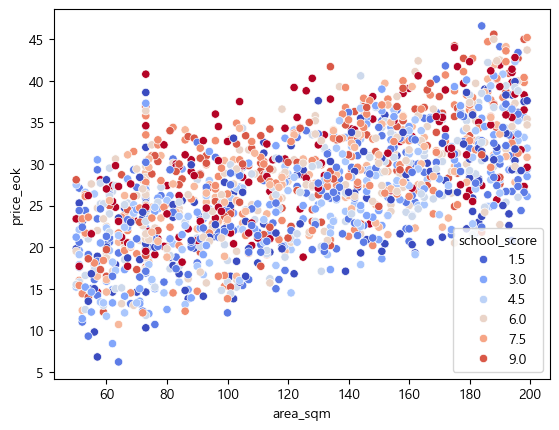

In [64]:
sns.scatterplot(data=estate_df, x='area_sqm', y='price_eok', hue='school_score', palette='coolwarm')

--- 
#### **문제 4.**

주요 건축 자재(`building_material`)에 따라 가격 분포가 어떻게 다른지 확인하려고 합니다. `seaborn`의 `violinplot`을 사용하여 `building_material`에 따른 `price_eok`의 분포를 시각화하고, 중앙값이 가장 큰 건축 자재를 `답안04` 변수에 문자열로 저장하세요.

* **x축**: `building_material`
* **y축**: `price_eok`
* **데이터**: `estate_df`

In [9]:
# 한글화를 위해 아래의 코드를 작성해 주세요.
import platform
from matplotlib import rc

if platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
else:  # Windows
    rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

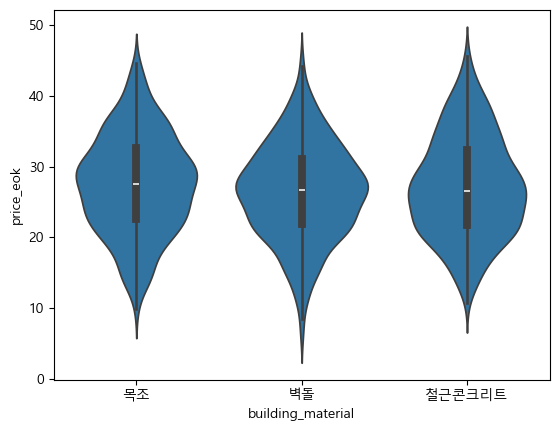

In [13]:
# 여기에 답안코드를 작성하세요.
sns.violinplot(data=estate_df, x='building_material', y='price_eok')
#시각적으로 중앙값이 가장 큰 건축 자재 모르겠음.
estate_df.groupby(['building_material'])['price_eok'].median()
답안04 = '목조'

building_material
목조        27.55
벽돌        26.70
철근콘크리트    26.60
Name: price_eok, dtype: float64

#### **[해설 및 핵심 이론] 문제 4**


* **상세 해설**  
    `violinplot`은 `boxplot`의 장점과 데이터의 밀도(Density) 그래프의 장점을 합친 형태로, 각 그룹의 데이터 분포를 더 상세하게 보여줍니다. 마치 바이올린 모양처럼 생긴 이 그래프의 넓은 부분은 데이터가 많이 모여있는 곳, 좁은 부분은 데이터가 드문드문 있는 곳을 의미합니다. 그래프를 보면 '목조' 자재의 중앙값(바이올린 내부의 흰 점)이 다른 자재에 비해 가장 위쪽에 위치해 있어, 평균적으로 목조 건물의 가격이 가장 높다는 것을 알 수 있습니다.

* **핵심 이론**  
    * **`sns.violinplot(data, x, y)`**: `boxplot`처럼 중앙값, 사분위수 범위를 보여주면서 동시에 데이터의 전체적인 분포 형태(어디에 데이터가 몰려있는지)까지 시각적으로 표현합니다. 데이터가 특정 값에 몰려있는지, 아니면 여러 개의 봉우리를 갖는지 등을 파악하기에 용이합니다.

In [ ]:
sns.violinplot(data=estate_df, x='building_material', y='price_eok')

# 그래프를 통해 '목조'의 중앙값이 가장 큰 것을 알 수 있습니다.
답안04 = '목조'

--- 
#### **문제 5.**

`region`별로 `subway_stations_1km`와 `amenities_500m`의 평균 개수를 확인하고자 합니다. `groupby()`를 사용하여 데이터를 `region`으로 그룹화하고, 두 편의시설 관련 컬럼의 평균을 계산하세요.

In [23]:
# 여기에 답안코드를 작성하세요.
estate_df.groupby(['region'])['subway_stations_1km'].mean()
estate_df.groupby(['region'])['amenities_500m'].mean()

region
강남    7.055310
강북    6.931464
기타    6.579710
마포    6.715753
서초    7.016835
Name: amenities_500m, dtype: float64

#### **[해설 및 핵심 이론] 문제 5**


* **상세 해설**  
    `groupby('region')`을 사용하여 데이터를 지역별로 그룹화합니다. 그 후, 분석 대상 컬럼인 `['subway_stations_1km', 'amenities_500m']`를 선택하고 `.mean()`으로 각 지역의 평균 편의시설 수를 계산합니다.

# [!], groupby시, [[]] 안에 두 개 확인 가능 => [['subway_stations_1km', 'amenities_500m']]

In [ ]:
# 'region'으로 그룹화하여 지하철역 수와 편의시설 수의 평균을 계산합니다.
region_infra_mean = estate_df.groupby('region')[['subway_stations_1km', 'amenities_500m']].mean()
region_infra_mean

--- 
#### **문제 6.**

모델링을 위해 데이터의 결측치를 처리하려고 합니다. 아래 가이드에 따라 결측치를 처리하고, 결과를 `estate_pre` 변수에 저장하세요.

1.  `estate_df` 데이터프레임을 복사하여 `estate_pre`를 생성합니다.
2.  수치형 컬럼인 `num_rooms`, `num_bathrooms`, `building_age`, `parking_spaces`, `subway_stations_1km`의 결측치는 각 컬럼의 `중앙값(median)`으로 채우세요.
3.  범주형 컬럼인 `building_material`의 결측치는 **'unknown'** 문자열로 채우세요.

In [38]:
# 여기에 답안코드를 작성하세요.
estate_pre = estate_df.copy()

col1 = ['num_rooms', 'num_bathrooms', 'building_age', 'parking_spaces', 'subway_stations_1km']
for col in col1 : 
    estate_pre[col] = estate_pre[col].fillna(estate_pre[col].median())

estate_pre['building_material'] = estate_pre['building_material'].fillna('unknown')



#### **[해설 및 핵심 이론] 문제 6**


* **상세 해설**  
    `copy()`로 데이터프레임을 복사합니다. 수치형 컬럼들의 리스트를 만들어 반복문을 통해 각 컬럼의 중앙값(`.median()`)을 계산하고, `fillna()`로 결측치를 채웁니다. 범주형 컬럼 `building_material`의 결측치는 `'unknown'` 문자열로 직접 채워줍니다. 수치형 데이터에서 평균 대신 중앙값을 사용하는 이유는, 이상치(outlier)의 영향을 덜 받기 때문입니다.

In [ ]:
# 원본 보존을 위해 데이터프레임을 복사합니다.
estate_pre = estate_df.copy()

# 1. 수치형 컬럼 결측치를 중앙값으로 채우기
numeric_cols_with_na = ['num_rooms', 'num_bathrooms', 'building_age', 'parking_spaces', 'subway_stations_1km']
for col in numeric_cols_with_na:
    median_val = estate_pre[col].median()
    estate_pre[col].fillna(median_val, inplace=True)

# 2. 범주형 컬럼 결측치를 'unknown'으로 채우기
estate_pre['building_material'].fillna('unknown', inplace=True)

# 전처리 결과 확인
estate_pre.info()

--- 
#### **문제 7.**

머신러닝 모델이 이해할 수 있도록 범주형 데이터를 수치형으로 변환하려고 합니다.  
`sklearn.preprocessing`의 `LabelEncoder`를 사용하여 `region`과 `building_material` 컬럼을 각각 레이블 인코딩하세요.

* `LabelEncoder` 객체를 생성하여 각 컬럼에 `fit_transform`을 적용하고, 변환된 결과를 다시 원래 데이터프레임의 해당 컬럼에 덮어쓰세요.

In [40]:
# 여기에 답안코드를 작성하세요.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

estate_pre['region'] = le.fit_transform(estate_pre['region'])
estate_pre['building_material'] = le.fit_transform(estate_pre['building_material'])

#### **[해설 및 핵심 이론] 문제 7**


* **상세 해설**  
    `LabelEncoder`는 범주형 데이터를 0부터 시작하는 정수로 변환합니다. `region`과 `building_material` 각 컬럼에 대해 `LabelEncoder` 객체를 생성하고 `fit_transform`을 적용하여 변환된 숫자 배열을 다시 원래 컬럼에 덮어씁니다. 원-핫 인코딩과 달리 컬럼의 수가 늘어나지 않는 장점이 있지만, 모델이 '서울=0, 부산=1, 인천=2'일 때, '인천이 서울보다 수학적으로 더 크다'고 잘못 오해할 수 있는 단점도 있습니다.

* **핵심 이론**
    * **`LabelEncoder()`**: n개의 범주형 데이터를 0, 1, 2, ..., n-1 과 같은 정수로 변환합니다.
        * `.fit_transform(데이터)`: 데이터에 어떤 값들이 있는지 학습(fit)하고, 그 규칙에 따라 바로 변환(transform)을 수행합니다.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 인코딩할 컬럼 리스트
categorical_cols_to_encode = ['region', 'building_material']

for col in categorical_cols_to_encode:
    # LabelEncoder 객체 생성
    le = LabelEncoder()
    # fit_transform을 적용하여 인코딩하고, 결과를 다시 해당 컬럼에 저장
    estate_pre[col] = le.fit_transform(estate_pre[col])

# 변환 결과 확인
estate_pre.head()

--- 
#### **문제 8.**

훈련과 검증에 사용할 데이터셋을 분리하려고 합니다.  
`price_eok` 컬럼을 label `y`로, 나머지 컬럼들을 feature `X`로 할당한 후 훈련 데이터셋과 검증 데이터셋으로 분리하는 코드를 작성하세요.

* **대상 데이터셋**: `estate_pre` (7번 문제까지 처리 완료된)
* `sklearn.model_selection`의 `train_test_split` 함수 사용
* **훈련:검증 데이터 비율**: 80:20
* **`random_state`**: 42 (결과 재현을 위해 고정)

In [41]:
# 여기에 답안코드를 작성하세요.
y = estate_pre['price_eok']
X = estate_pre.drop('price_eok', axis=1)

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

#### **[해설 및 핵심 이론] 문제 8**


* **상세 해설**  
    `drop()`을 사용하여 `price_eok` 컬럼을 제외한 나머지를 `X`로, `price_eok` 컬럼을 `y`로 분리합니다.  
   `train_test_split` 함수에 `X`와 `y`, `test_size=0.2` (검증 데이터 20%), `random_state=42`를 설정하여 데이터를 분리합니다.

In [ ]:
from sklearn.model_selection import train_test_split

# Feature(X)와 Label(y)을 분리합니다.
X = estate_pre.drop('price_eok', axis=1)
y = estate_pre['price_eok']

# 훈련 데이터와 검증 데이터로 분리합니다.
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 분리 결과 확인
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

--- 
#### **문제 9.**

수치형 데이터들의 단위를 맞춰주기 위해 데이터 스케일링을 진행합니다.  
평균을 0, 표준편차를 1로 변환하는 `StandardScaler`를 사용하여 훈련 데이터와 검증 데이터의 Feature(`X_train`, `X_valid`)를 스케일링하는 코드를 작성하세요.

* `sklearn.preprocessing`의 `StandardScaler` 함수 사용
* 훈련 데이터에는 `fit_transform()`을, 검증 데이터에는 `transform()`을 적용하세요.
* 스케일링된 결과는 각각 `X_train_scaled`, `X_valid_scaled` 변수에 저장하세요.

In [42]:
# 여기에 답안코드를 작성하세요.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

#### **[해설 및 핵심 이론] 문제 9**


* **상세 해설**  
    `StandardScaler` 객체를 생성합니다. `MinMaxScaler`와 마찬가지로, **훈련 데이터(`X_train`)에는 `fit_transform()`을 적용**하여 스케일링 규칙(평균, 표준편차)을 학습하고 변환하며, **검증 데이터(`X_valid`)에는 `transform()`만 적용**하여 데이터 누수를 방지합니다.

* **핵심 이론**  
    * **`StandardScaler()`**: 각 특성의 평균을 0, 표준편차를 1이 되도록 데이터를 변환합니다. 마치 모든 학생의 점수를 반 평균과 비교하여 '평균보다 몇 점 위/아래'인지를 나타내는 '표준점수'로 바꾸는 것과 같습니다. 딥러닝을 포함한 많은 알고리즘에서 안정적인 성능을 보여 널리 사용됩니다.

In [ ]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
scaler = StandardScaler()

# 훈련 데이터에 fit_transform 적용
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터에 transform 적용
X_valid_scaled = scaler.transform(X_valid)

--- 
#### **문제 10.**

선형 회귀 모델 중 하나인 `Ridge` 회귀 모델을 사용하여 부동산 가격 예측 모델을 학습시키려고 합니다. 아래 가이드에 따라 모델을 생성하고 학습시키는 코드를 작성하세요.  
`.predict()`를 사용하여 검증 데이터에 대한 예측값을 `ridge_pred`에 저장합니다.

* `sklearn.linear_model`의 `Ridge` 함수 사용
* **하이퍼파라미터 설정**:
    * `alpha`: 1.0
    * `random_state`: 42
* 모델 객체는 `model_ridge` 변수에 저장하고, 스케일링된 훈련 데이터로 학습시키세요.

In [45]:
# 여기에 답안코드를 작성하세요.
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train_scaled, y_train)

ridge_pred = model_ridge.predict(X_valid_scaled)

#### **[해설 및 핵심 이론] 문제 10**


* **상세 해설**
  
    `Ridge`는 기본적인 선형 회귀 모델에 '과적합 방지 장치'(L2 규제)를 추가한 모델입니다. 이 장치는 모델이 특정 데이터의 특징에 너무 과하게 반응(학습)하여, 새로운 데이터에 대한 예측력이 떨어지는 현상을 막아줍니다. `alpha` 값은 이 장치를 얼마나 강하게 작동시킬지를 조절하는 스위치와 같습니다.

* **핵심 이론**
    * **`Ridge(alpha)`**: 선형 회귀 모델의 한 종류로, 과적합(모델이 훈련 데이터에만 너무 맞춰지는 현상)을 제어하는 데 효과적입니다. `alpha` 값이 클수록 제어 장치가 강하게 작동하여 모델이 단순해지고, 작을수록 일반적인 선형 회귀 모델처럼 자유롭게 학습합니다.

In [ ]:
from sklearn.linear_model import Ridge

# Ridge 모델 객체 생성
model_ridge = Ridge(alpha=1.0, random_state=42)

# 모델 학습
model_ridge.fit(X_train_scaled, y_train)

# 모델 예측
ridge_pred = model_ridge.predict(X_valid_scaled)

--- 
#### **문제 11.**

이번에는 `LGBMRegressor` 모델을 사용하여 학습을 진행하고, 이 모델의 예측 성능을 확인하려고 합니다. 아래 가이드에 따라 모델을 학습시키고, 검증 데이터셋(`X_valid_scaled`)에 대한 예측 결과를 `lgbm_pred` 변수에 저장하세요.

* `lightgbm`의 `LGBMRegressor` 함수 사용 (1번 문제에서 `lgb`로 임포트)
* **하이퍼파라미터 설정**:
    * `n_estimators`: 200
    * `learning_rate`: 0.05
    * `random_state`: 42
* 모델 객체는 `model_lgbm` 변수에 저장하고 학습시키세요.

In [44]:
# 여기에 답안코드를 작성하세요.
import lightgbm as lgb

model_lgbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model_lgbm.fit(X_train_scaled, y_train)

lgbm_pred = model_lgbm.predict(X_valid_scaled)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000949 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 247
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] Start training from score 27.126667


C:\Users\dothe\anaconda3\envs\pyt39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#### **[해설 및 핵심 이론] 문제 11**

* **상세 해설**  
  
    `LGBMRegressor`는 XGBoost와 함께 그래디언트 부스팅 계열에서 가장 성능이 좋은 모델 중 하나로, 특히 대용량 데이터에서 빠른 학습 속도를 자랑합니다. 문제에서 제시된 하이퍼파라미터로 모델 객체 `model_lgbm`를 생성하고 학습시킨 후, `.predict()`를 사용하여 검증 데이터에 대한 예측값을 `lgbm_pred`에 저장합니다.

In [ ]:
import lightgbm as lgb
    
# LGBMRegressor 모델 객체 생성
model_lgbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)

# 모델 학습
model_lgbm.fit(X_train_scaled, y_train)

# 검증 데이터에 대한 예측 수행
lgbm_pred = model_lgbm.predict(X_valid_scaled)

--- 
#### **문제 12.**

앞서 학습한 두 머신러닝 모델(`model_ridge`, `model_lgbm`)의 성능을 평가하려고 합니다.  
회귀 모델의 성능을 평가하는 대표적인 지표인 **MAE(Mean Absolute Error)** 와 **R² Score(결정계수)** 를 계산하는 코드를 작성하세요.

* `sklearn.metrics`에서 `mean_absolute_error`, `r2_score` 함수를 import하세요.
* 두 모델에 대해 각각 `y_valid`와 예측값을 사용하여 두 가지 평가지표를 모두 계산하고 출력하세요.

In [49]:
# 여기에 답안코드를 작성하세요.
from sklearn.metrics import mean_squared_error, r2_score

print("----model_ridge----")
print(f'mean_absolute_error : { mean_squared_error(y_valid, ridge_pred )} ' )
print(f'r2 score : {r2_score(y_valid, ridge_pred) }')

print("----model_lgbm----")
print(f'mean_absolute_error : { mean_squared_error(y_valid, lgbm_pred) } ' )
print(f'r2 score : {r2_score(y_valid, lgbm_pred) }')

----model_ridge----
mean_absolute_error : 16.32168977473349 
r2 score : 0.6409679308727718
----model_lgbm----
mean_absolute_error : 3.4508669777565757 
r2 score : 0.9240904631562881


#### **[해설 및 핵심 이론] 문제 12**

* **상세 해설**
  
    `mean_absolute_error`와 `r2_score` 함수를 임포트합니다. 각 모델에 대해 예측값을 구하고, 평가 함수에 `(실제값, 예측값)` 순서로 인자를 넣어 성능 지표를 계산합니다. MAE는 (실제값 - 예측값)의 절댓값에 대한 평균으로, MSE(평균 제곱 오차)보다 이상치(매우 비싸거나 싼 특이한 매물)의 영향을 덜 받습니다. 또한 '평균적으로 약 3.5억 정도 오차가 난다'처럼 결과를 직관적으로 해석하기 좋은 장점이 있습니다.

* **핵심 이론**
    * **`mean_absolute_error(y_true, y_pred)`**: 평균 절대 오차를 계산합니다. (실제값 - 예측값)의 절댓값에 대한 평균이며, 값이 **작을수록** 좋습니다.
    * **`r2_score(y_true, y_pred)`**: 결정계수를 계산하며, **1에 가까울수록** 좋습니다.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ridge 모델 성능 평가
ridge_mae = mean_absolute_error(y_valid, ridge_pred)
ridge_r2 = r2_score(y_valid, ridge_pred)

print("--- Ridge Regressor 성능 ---")
print(f"MAE: {ridge_mae:.4f}")
print(f"R² Score: {ridge_r2:.4f}\n")

# 2. LGBMRegressor 모델 성능 평가 (11번 문제의 예측값 사용)
lgbm_mae = mean_absolute_error(y_valid, lgbm_pred)
lgbm_r2 = r2_score(y_valid, lgbm_pred)

print("--- LGBMRegressor 성능 ---")
print(f"MAE: {lgbm_mae:.4f}")
print(f"R² Score: {lgbm_r2:.4f}")

--- 
#### **문제 13.**

이번에는 딥러닝을 사용하여 가격 예측 모델을 만들려고 합니다.  
아래의 가이드에 따라 `tensorflow.keras`를 사용하여 회귀 모델을 구축하고 학습시키세요. 이번 모델에는 과적합을 방지하기 위해 `Dropout` 레이어를 추가합니다.

* `Sequential` 모델을 사용하세요.
* **모델 구조**:
    * **입력층**: `Dense` 레이어, 64개 노드, 활성화 함수 `relu`
    * **Dropout**: 20%의 뉴런을 비활성화 (`Dropout(0.2)`)
    * **은닉층 1**: `Dense` 레이어, 32개 노드, 활성화 함수 `relu`
    * **출력층**: `Dense` 레이어, **1개 노드**
* **컴파일 설정**:
    * `optimizer`: `adam`
    * `loss`: `mean_absolute_error` (MAE)
* **학습 설정**:
    * `epochs`: 100
    * `batch_size`: 16
    * `validation_split`: 훈련 데이터 중 20%를 검증용으로 사용
* 학습 과정은 `history` 변수에 저장하세요.

In [59]:
# 여기에 답안코드를 작성하세요.
import tensorflow 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_dim=X_train_scaled.shape[1])
    ,Dropout(0.2)
    ,Dense(32, activation='relu')
    ,Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mean_absolute_error')
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2)



Epoch 1/100
60/60 [==============================] - 1s 4ms/step - loss: 25.3021 - val_loss: 21.5516
Epoch 2/100
60/60 [==============================] - 0s 2ms/step - loss: 15.6572 - val_loss: 7.3035
Epoch 3/100
60/60 [==============================] - 0s 2ms/step - loss: 5.1976 - val_loss: 3.3542
Epoch 4/100
60/60 [==============================] - 0s 2ms/step - loss: 4.2507 - val_loss: 3.3488
Epoch 5/100
60/60 [==============================] - 0s 2ms/step - loss: 4.0232 - val_loss: 3.0007
Epoch 6/100
60/60 [==============================] - 0s 2ms/step - loss: 3.7555 - val_loss: 2.8632
Epoch 7/100
60/60 [==============================] - 0s 2ms/step - loss: 3.6313 - val_loss: 2.7747
Epoch 8/100
60/60 [==============================] - 0s 3ms/step - loss: 3.5233 - val_loss: 2.6233
Epoch 9/100
60/60 [==============================] - 0s 2ms/step - loss: 3.3737 - val_loss: 2.5032
Epoch 10/100
60/60 [==============================] - 0s 2ms/step - loss: 3.1688 - val_loss: 2.3931
Epoch 

#### **[해설 및 핵심 이론] 문제 13**

* **상세 해설**
  
    `Sequential` 모델을 만들고 `Dense` 레이어 사이에 `Dropout` 레이어를 추가합니다. `Dropout(0.2)`는 일종의 '팀워크 훈련' 장치입니다. 학습할 때마다 팀원(데이터를 처리하는 작은 단위인 뉴런) 중 20%를 무작위로 쉬게 만들어, 몇몇 에이스 팀원에게만 의존하지 않고 팀 전체가 협력하여 문제를 해결하는 능력을 기르도록 합니다. 이는 모델이 훈련 데이터에만 너무 익숙해지는 과적합 현상을 막는 데 매우 효과적입니다. `fit` 함수에서 `validation_split=0.2` 옵션은 별도의 검증 데이터를 지정하는 대신, 훈련 데이터의 마지막 20%를 검증용으로 사용하겠다는 의미입니다.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 딥러닝 모델 설계
model_dl = Sequential([
    Dense(64, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# 모델 컴파일
model_dl.compile(optimizer='adam', loss='mean_absolute_error')

# 모델 학습
history = model_dl.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2, # 훈련 데이터의 20%를 검증용으로 사용
    verbose=0 # 학습 과정 출력 생략
)

print("딥러닝 모델 학습 완료")
model_dl.evaluate(X_valid_scaled, y_valid)

--- 
#### **문제 14.**

최종적으로 완성된 딥러닝 모델을 사용하여, 아래와 같은 새로운 부동산 데이터가 들어왔을 때의 가격을 예측하려고 합니다.  
주어진 시뮬레이션 데이터(`new_estate_data`)를 **9번 문제에서 생성한 스케일러(`scaler`)를 사용하여 변환**한 뒤, 딥러닝 모델로 가격을 예측하는 코드를 작성하세요.

* 예측 결과는 `predicted_price_dl` 변수에 저장하세요.

In [61]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_estate_data = np.array([[0, 120.0, 3.0, 2.0, 10.0, 1, 2.0, 2.0, 8.0, 9.0]])

In [63]:
# 여기에 답안코드를 작성하세요.
new_estate_data = scaler.transform(new_estate_data)

predicted_price_dl = model.predict(new_estate_data)
predicted_price_dl


1/1 [==============================] - 0s 34ms/step


C:\Users\dothe\anaconda3\envs\pyt39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[31.551382]], dtype=float32)

#### **[해설 및 핵심 이론] 문제 14**

* **상세 해설**

    새로운 데이터 `new_estate_data`는 스케일링되지 않은 원본 형태이므로, **반드시 9번 문제에서 훈련 데이터로 학습시킨 `scaler` 객체를 사용하여 `transform()`** 해야 합니다. 스케일링된 데이터를 학습된 딥러닝 모델 `model_dl`의 `.predict()` 메소드에 입력하여 가격을 예측하고, 그 결과를 `predicted_price_dl` 변수에 저장합니다.

In [ ]:
# 1. 9번 문제의 scaler를 사용하여 새로운 데이터를 스케일링합니다.
new_estate_scaled = scaler.transform(new_estate_data)

# 2. 딥러닝 모델로 가격을 예측합니다.
predicted_price_dl = model_dl.predict(new_estate_scaled)

print(f"새로운 부동산의 예측 가격: {predicted_price_dl[0][0]:.2f} 억원")